In [71]:
import harmonica as hm
import numpy as np
import verde as vd
import boule as bl

## Cartesian coordinates

Define the point source and its mass (in kg).

In [72]:
point = (400, 300, 200)
mass = 1e6

Define a computation point located 100m above the point source.

In [73]:
coordinates = (point[0], point[1], point[2] + 100)

In [74]:
potential = hm.point_gravity(coordinates, point, mass, field="potential")
print(f'Gravitational potential field: {np.float64(potential):.4e} J/kg')

Gravitational potential field: 6.6743e-07 J/kg


## Working with multiple sources

In [130]:
easting = np.array([250, 850, 150, 650])
northing = np.array([250, 350, 750, 750])
upward = np.array([-100, -200, -100, -200])
points = (easting, northing, upward)

masses = np.array([1e6, -1e6, 2e6, -3e6])

We can define a set of computation points located on a regular grid at zero height.

In [131]:
coordinates = vd.grid_coordinates(
    region=(-250, 1250, -250, 1250), shape=(40, 40), extra_coords=0
)

In [132]:
g_z = hm.point_gravity(coordinates, points, masses, field="g_z")

In [133]:
import pygmt

# Needed so that displaying works on jupyter-sphinx and sphinx-gallery at
# the same time. Using PYGMT_USE_EXTERNAL_DISPLAY="false" in the Makefile
# for sphinx-gallery to work means that fig.show won't display anything here
# either.
pygmt.set_display(method="notebook")

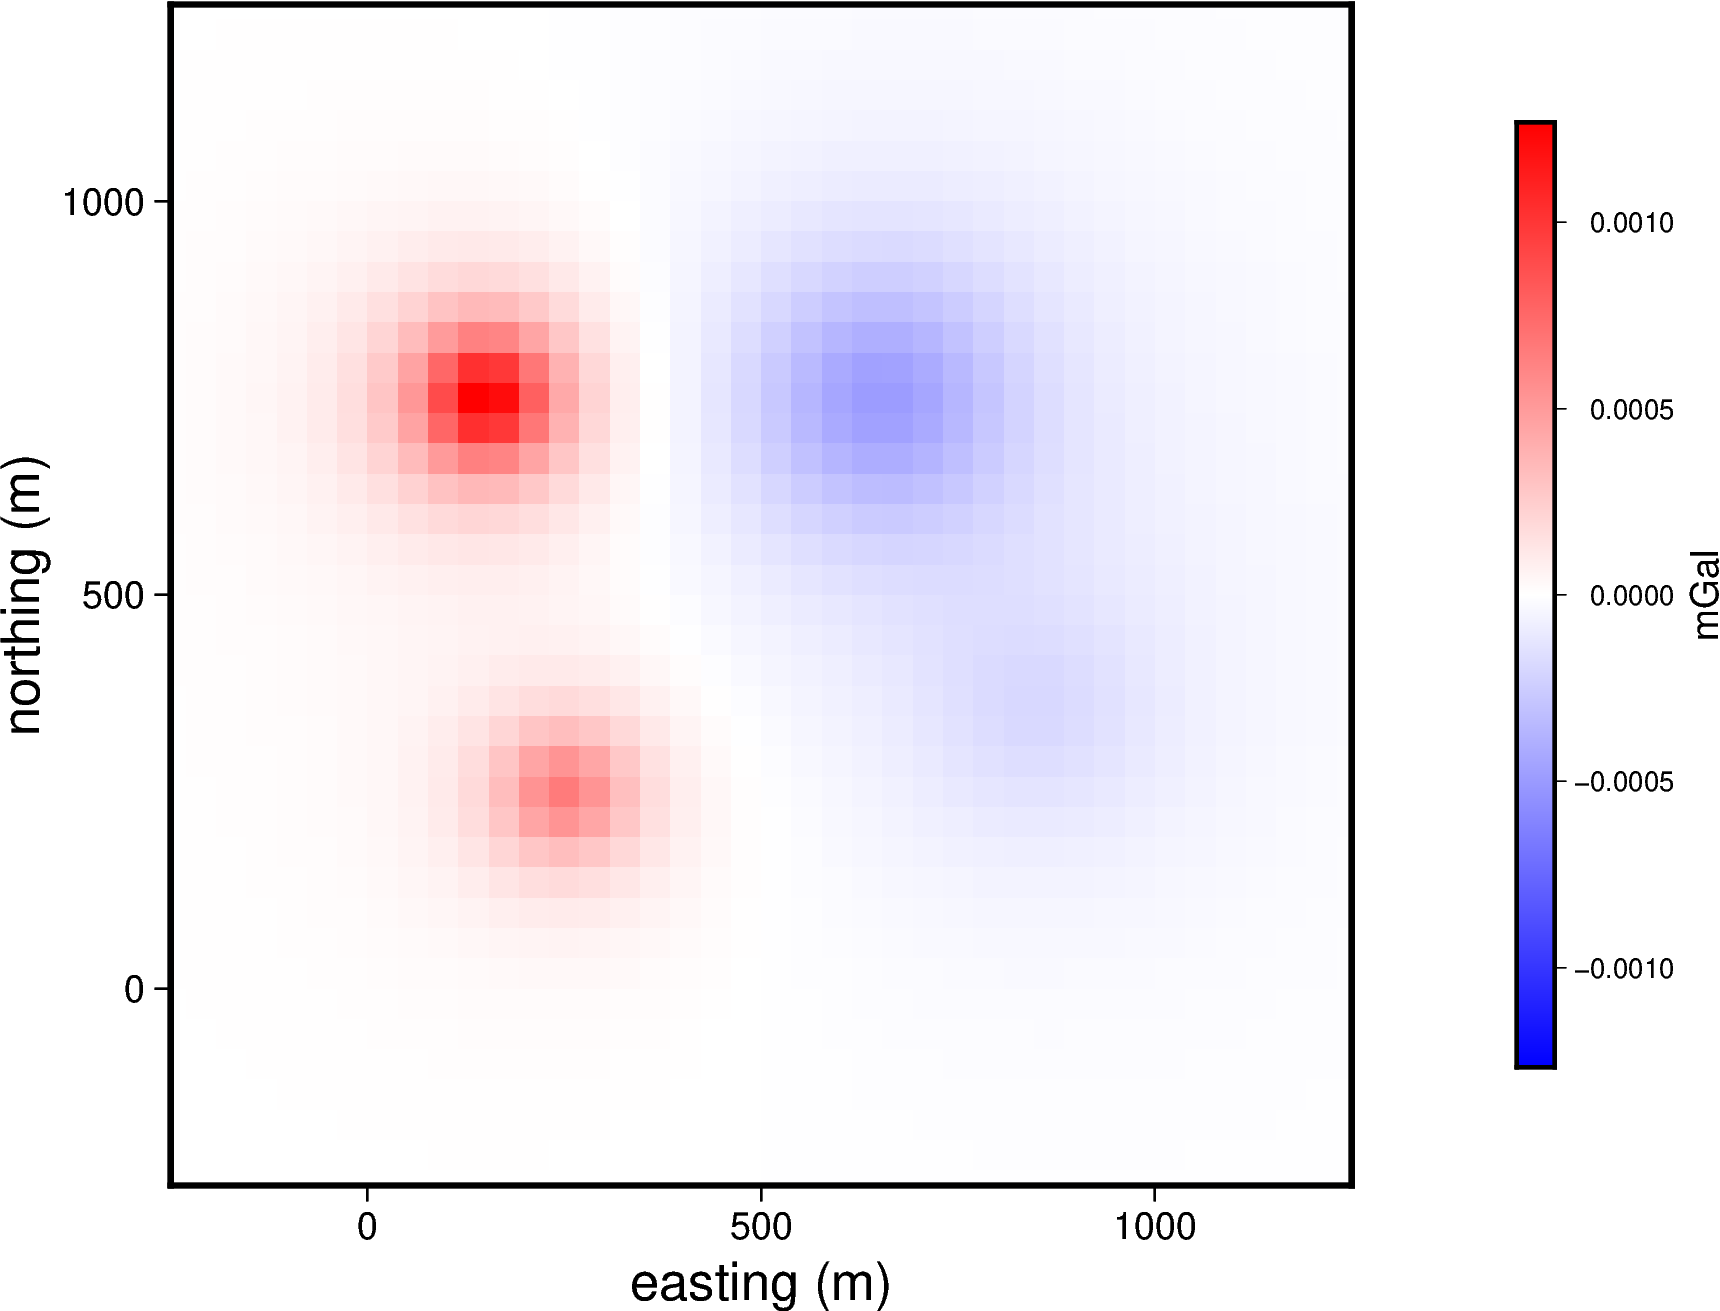

In [134]:
grid = vd.make_xarray_grid(
   coordinates, g_z, data_names="g_z", extra_coords_names="extra")

fig = pygmt.Figure()

maxabs = vd.maxabs(g_z)
pygmt.makecpt(cmap="polar", series=(-maxabs, maxabs), background=True)

fig.grdimage(
   region=(-250, 1250, -250, 1250),
   projection="X10c",
   grid=grid.g_z,
   frame=["a", "x+leasting (m)", "y+lnorthing (m)"],
   cmap=True,)
fig.colorbar(cmap=True, position="JMR", frame=["a.0005", "x+lmGal"])
fig.show()

## Spherical coordinates using Boule

Let's define a single point source in the equator, at a longitude of 45 degrees and located on the surface of the WGS84 ellipsoid.

In [30]:
ellipsoid = bl.WGS84

In [146]:
longitude, latitude = 45, 0
radius = ellipsoid.geocentric_radius(latitude)
point = (longitude, latitude, radius)

mass = 1e6

In [147]:
coordinates = (point[0], point[1], point[2] + 1000)

In [148]:
g_z = hm.point_gravity(
    coordinates, point, mass, field="g_z", coordinate_system="spherical"
)
print(f'Gravitational field: {(g_z):.4e} mGal')

Gravitational field: 6.6743e-06 mGal


## Working with sources defined in geodetic coordinates

Let's define a set point sources in geodetic coordinates and their masses.

In [179]:
longitude = np.array([-71, -72, -70, -69])
latitude = np.array([-42, -43, -45, -44])
height = np.array([-10e3, -20e3, -30e3, -20e3])
points = (longitude, latitude, height)

masses = np.array([1e6, -2e6, -3e6, 4e6])

In [180]:
coordinates = vd.grid_coordinates(
    region=(-73, -68, -46, -41),
    shape=(101, 101),
    extra_coords=20e3,
)

Now we convert to spherical.

In [181]:
points_spherical = ellipsoid.geodetic_to_spherical(points)
coordinates_spherical = ellipsoid.geodetic_to_spherical(coordinates)

In [182]:
g_z = hm.point_gravity(
    coordinates_spherical,
    points_spherical,
    masses,
    field="g_z",
    coordinate_system="spherical",
)

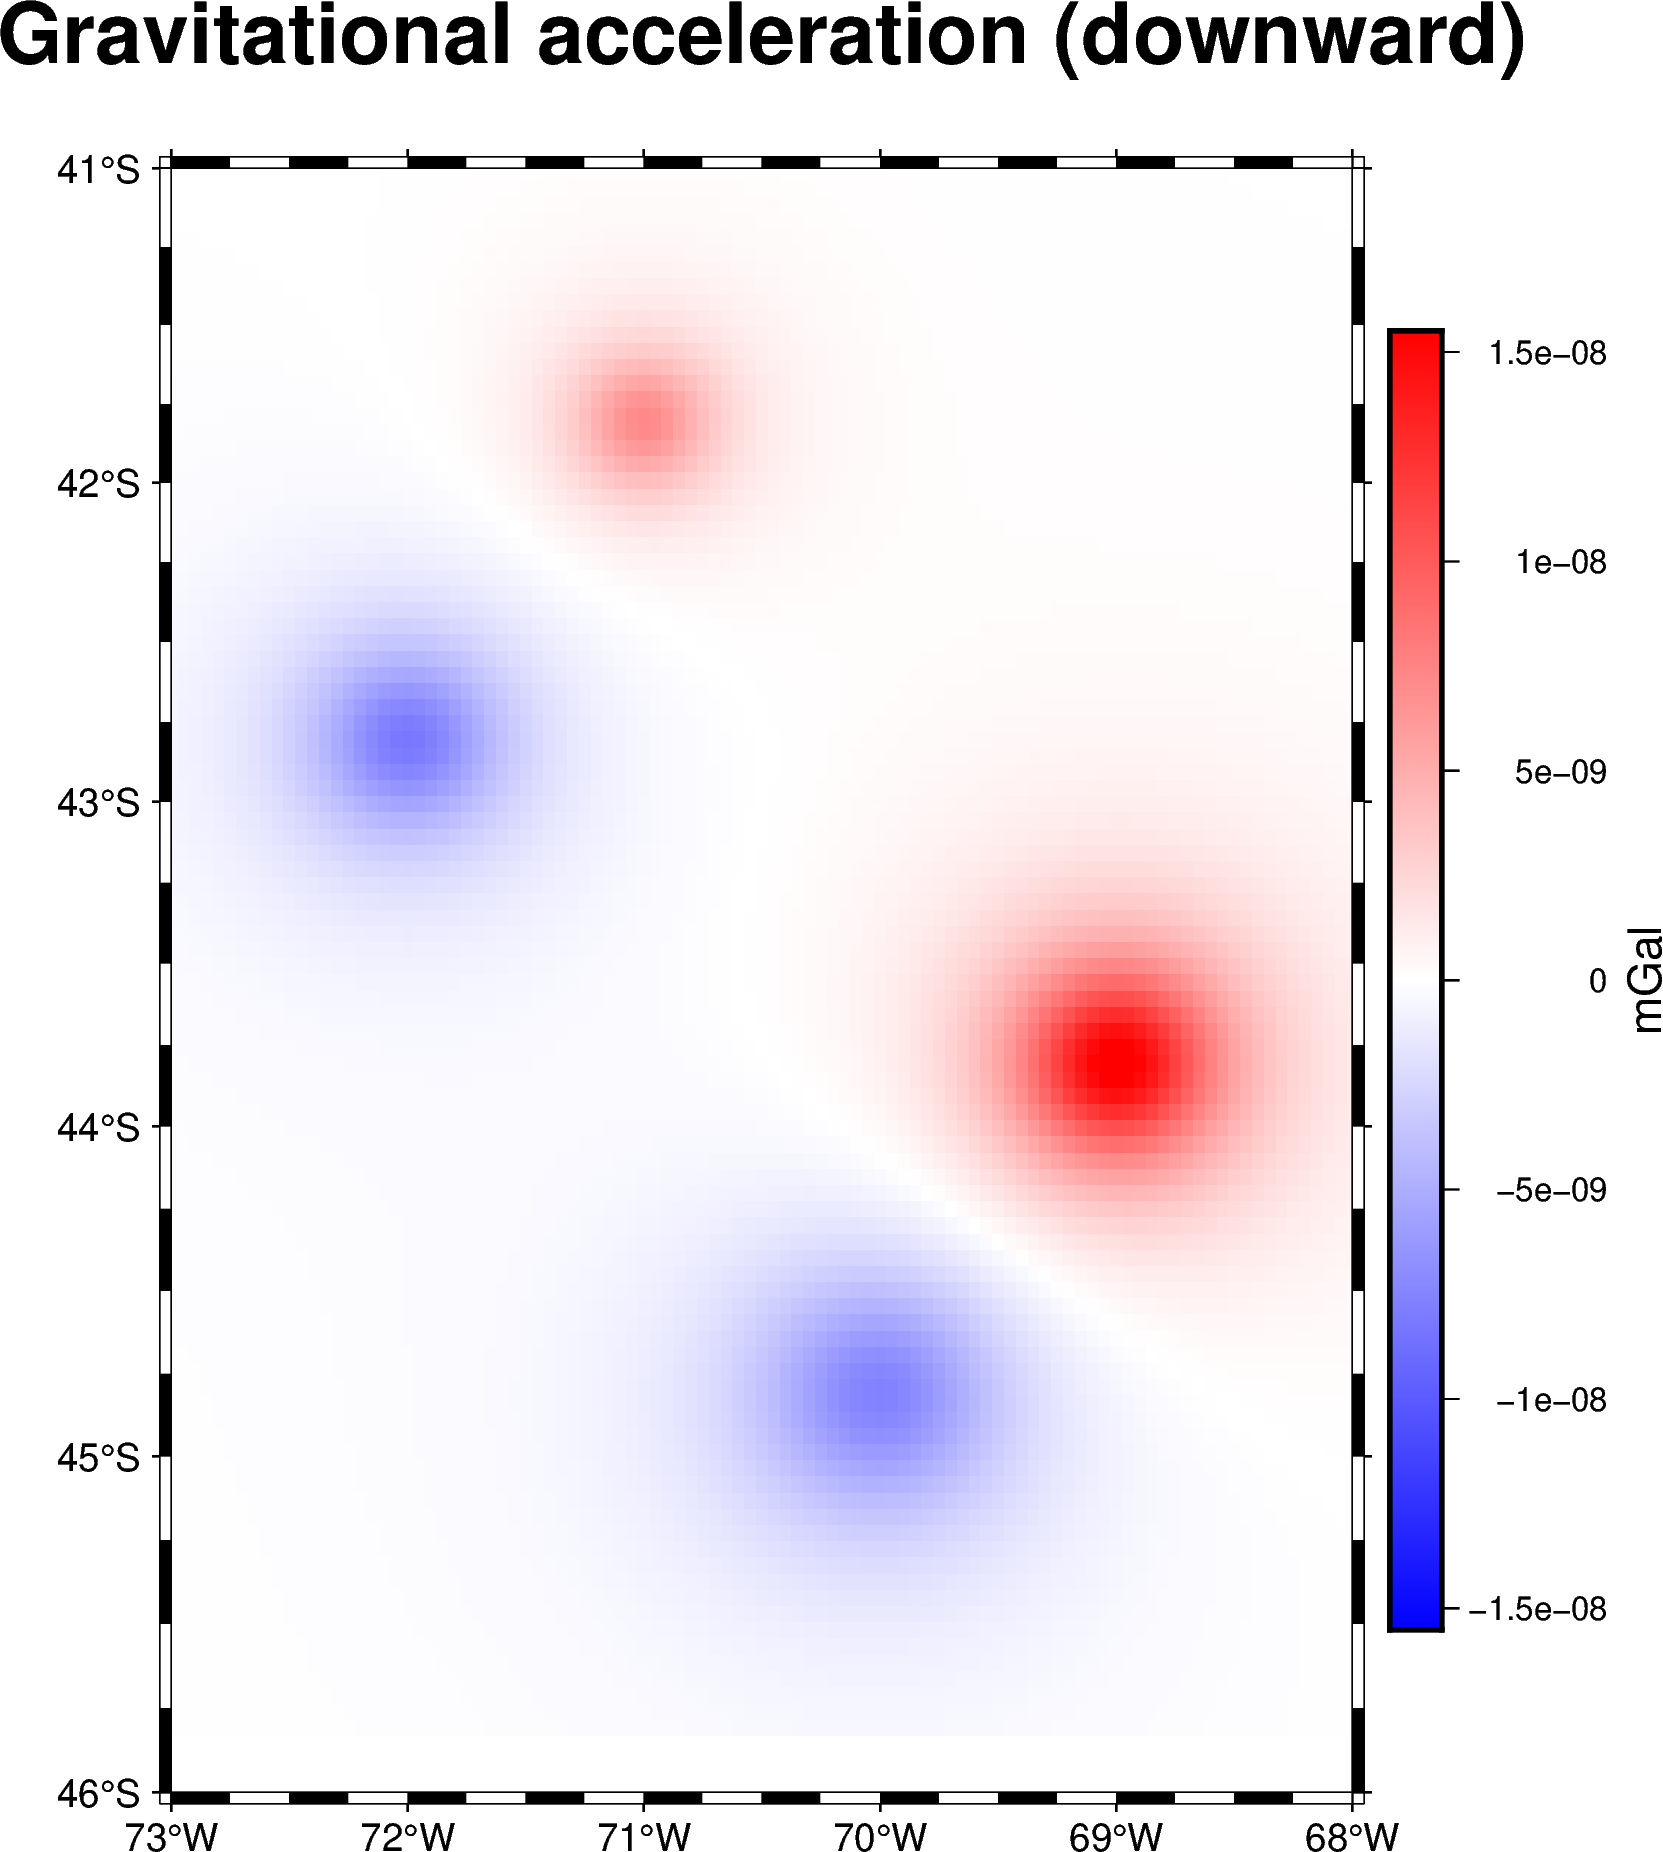

In [183]:
grid = vd.make_xarray_grid(
   coordinates_spherical, g_z, data_names="g_z", extra_coords_names="extra")

fig = pygmt.Figure()
title = "Gravitational acceleration (downward)"
maxabs = vd.maxabs(g_z)*.95
pygmt.makecpt(cmap="polar", series=(-maxabs, maxabs), background=True)

fig.grdimage(
   region=(-73, -68, -46, -41),
   projection="M10c",
   grid=grid.g_z,
   frame=[f"WSne+t{title}", "x", "y"],
   cmap=True,)

fig.colorbar(cmap=True, position="JMR", frame=["a0.000000005", "x+lmGal"])
fig.show()